In [3]:
from skyfield.api import load
import numpy as np
import matplotlib.pyplot as plt

In [25]:
eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()

year = 761
# 扫描4月1日到6月30日 (共91天)
start_day = 1   # 4月1日
end_day = 30    # 6月30日
month_days = {7:31, 8:31, 9:30}

min_overall = 1e9
best_date = None
best_ut = None

for month in [7,8,9]:
    for day in range(1, month_days[month]+1):
        ut_hours = np.arange(0, 24, 0.2)   # 步长0.2小时 = 12分钟，够用了
        min_sep = 1e9
        for ut in ut_hours:
            t = ts.ut1(year, month, day, ut)
            # 直接UT计算几何角距，无需转换TT（因为几何位置与ΔT无关，只要时刻一致即可）
            astro_s = earth.at(t).observe(sun)
            astro_m = earth.at(t).observe(moon)
            sep = astro_s.separation_from(astro_m).degrees
            if sep < min_sep:
                min_sep = sep
                min_ut = ut
        print(f"{year}-{month:02d}-{day:02d} 最小角距: {min_sep:.4f}° @ UT {min_ut:.2f}")
        if min_sep < min_overall:
            min_overall = min_sep
            best_date = (year, month, day)
            best_ut = min_ut

print("\n" + "="*50)
print(f"最佳日期: {best_date[0]}-{best_date[1]:02d}-{best_date[2]:02d}, 最小角距: {min_overall:.4f}°, UT={best_ut:.2f}")

761-07-01 最小角距: 116.2821° @ UT 23.80
761-07-02 最小角距: 104.5316° @ UT 23.80
761-07-03 最小角距: 92.4578° @ UT 23.80
761-07-04 最小角距: 80.0104° @ UT 23.80
761-07-05 最小角距: 67.1533° @ UT 23.80
761-07-06 最小角距: 53.8783° @ UT 23.80
761-07-07 最小角距: 40.2186° @ UT 23.80
761-07-08 最小角距: 26.2653° @ UT 23.80
761-07-09 最小角距: 12.2248° @ UT 23.80
761-07-10 最小角距: 2.6007° @ UT 20.00
761-07-11 最小角距: 3.5382° @ UT 0.00
761-07-12 最小角距: 16.6930° @ UT 0.00
761-07-13 最小角距: 30.4038° @ UT 0.00
761-07-14 最小角距: 43.7753° @ UT 0.00
761-07-15 最小角距: 56.7060° @ UT 0.00
761-07-16 最小角距: 69.1762° @ UT 0.00
761-07-17 最小角距: 81.2127° @ UT 0.00
761-07-18 最小角距: 92.8714° @ UT 0.00
761-07-19 最小角距: 104.2239° @ UT 0.00
761-07-20 最小角距: 115.3476° @ UT 0.00
761-07-21 最小角距: 126.3180° @ UT 0.00
761-07-22 最小角距: 137.2041° @ UT 0.00
761-07-23 最小角距: 148.0649° @ UT 0.00
761-07-24 最小角距: 158.9459° @ UT 0.00
761-07-25 最小角距: 169.8616° @ UT 0.00
761-07-26 最小角距: 167.8025° @ UT 23.80
761-07-27 最小角距: 156.5034° @ UT 23.80
761-07-28 最小角距: 145.0108° @ UT 23.

最佳 TT 时刻: <Time tt=1999229.6805555555>
儒略日 (TT): 1999229.6805555555
对应日历 (TT): (761, 8, 9, 4, 20, 1.8189894035458565e-12)
最小角距离: 0.146252 度
视直径比例 (月/日): 1.036291 (大于1表示月亮更大，全食条件)
此时 ΔT (理论): 3246.03 秒


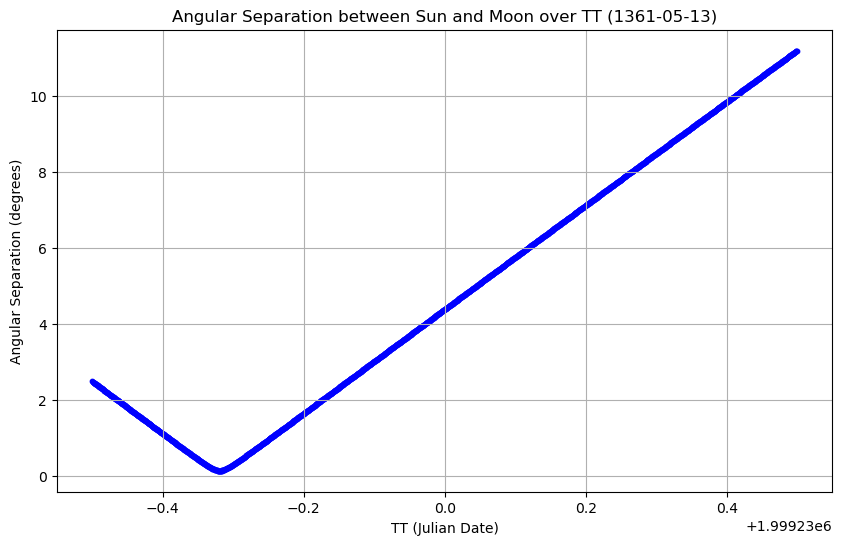

In [27]:
from skyfield.api import load
import numpy as np
import matplotlib.pyplot as plt

eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()

# 1361年5月13日（公历），松江附近（坐标不影响地心几何）
year, month, day = 761, 8, 9
hour_min, hour_max = 0, 24
hours = np.arange(hour_min, hour_max)
minutes = np.arange(0, 60)
h_mesh, m_mesh = np.meshgrid(hours, minutes)
tt_steps = ts.tt(year, month, day, h_mesh.flatten(), m_mesh.flatten())

# 地心几何角距离
astrometric_sun = earth.at(tt_steps).observe(sun)
astrometric_moon = earth.at(tt_steps).observe(moon)
separation = astrometric_sun.separation_from(astrometric_moon)
index = np.argmin(separation.arcseconds())
tt_best = tt_steps[index]
min_sep = separation.degrees[index]
print(f"最佳 TT 时刻: {tt_best}")
print(f"儒略日 (TT): {tt_best.tt}")
print(f"对应日历 (TT): {tt_best.tt_calendar()}")
print(f"最小角距离: {min_sep:.6f} 度")
# 视直径比例
dist_sun = astrometric_sun[index].distance().au
dist_moon = astrometric_moon[index].distance().au
ratio = (3474 / dist_moon) / (1392700 / dist_sun)
print(f"视直径比例 (月/日): {ratio:.6f} (大于1表示月亮更大，全食条件)")
print(f"此时 ΔT (理论): {tt_best.delta_t:.2f} 秒")

# 绘制角距离随 TT 的变化
plt.figure(figsize=(10,6))
plt.title("Angular Separation between Sun and Moon over TT (1361-05-13)")
plt.xlabel("TT (Julian Date)")
plt.ylabel("Angular Separation (degrees)")
plt.grid()
plt.scatter(tt_steps.tt, separation.degrees, s=10, color='blue', label='Angular Separation')
plt.show()

In [37]:
from skyfield.api import load, wgs84
import numpy as np

# 1. 初始化
eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()
qufu = earth + wgs84.latlon(34.203, 108.9339)

year, m, d = 761, 8, 9
# 保持高密度采样
ut1_hours = np.arange(2, 4, 1.0/60.0) 

def check_totality(test_dt):
    # A. 既然 TT = UT1 + Delta_T
    # 我们先得到一系列 TT 的儒略日
    t_temp = ts.ut1(year, m, d, ut1_hours)
    # 计算对应的 TT 儒略日：当前的 UT1 + 我们要测试的 Delta T
    jd_tt = t_temp.ut1 + test_dt / 86400.0
    
    # B. 使用官方推荐的 tt_jd 构造时间对象
    # 此时生成的 t 对象，其内置的 delta_t 是 Skyfield 用默认模型算出来的
    t = ts.tt_jd(jd_tt)
    
    # C. 【核心黑客操作】强制覆盖该对象的 delta_t 属性
    # Skyfield 计算地面位置时会读取 t.delta_t
    t.delta_t = np.array([test_dt] * len(jd_tt))
    
    # 3. 几何判定
    obs_s = qufu.at(t).observe(sun).apparent()
    obs_m = qufu.at(t).observe(moon).apparent()
    
    sep = obs_s.separation_from(obs_m).radians
    # 使用 IAU 常数和更精确的半径计算
    r_sun = np.arcsin(695700.0 / obs_s.distance().km)
    r_moon = np.arcsin(1737.4 / obs_m.distance().km)
    
    is_bigger = r_moon > r_sun
    is_covered = sep < (r_moon - r_sun)
    
    return np.any(is_bigger & is_covered)

# 4. 执行扫描
dt_range = np.arange(1000, 3500, 1) # 步长缩短到 1s 提高命中率
valid_dts = []

print("正在通过属性注入方式扫描 ΔT...")
for d_t in dt_range:
    if check_totality(d_t):
        valid_dts.append(d_t)

if valid_dts:
    print("-" * 40)
    print(f"复现范围: {min(valid_dts)} s ~ {max(valid_dts)} s")
else:
    print("未找到结果。")

正在通过属性注入方式扫描 ΔT...
----------------------------------------
复现范围: 1670 s ~ 3209 s


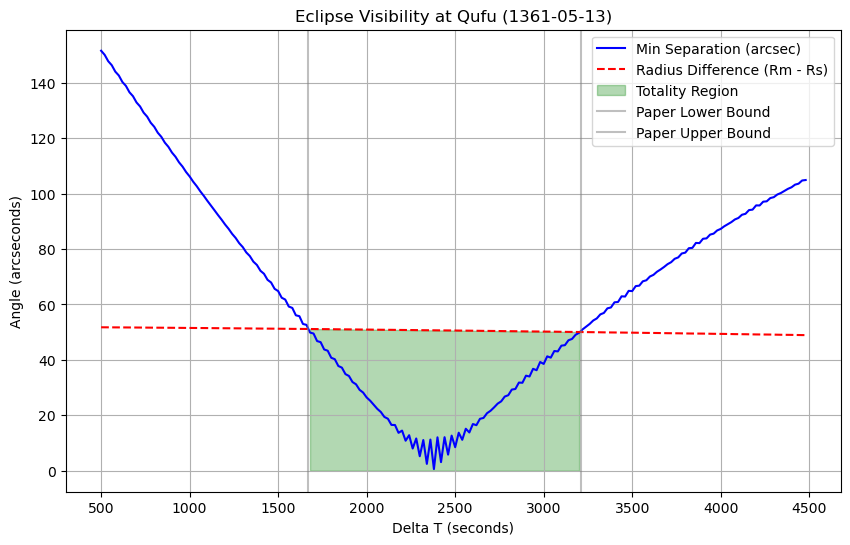

In [43]:
import matplotlib.pyplot as plt

# 1. 设置扫描参数
dt_test_range = np.arange(500, 4500, 20) # 步长 20s，扩大搜索范围
min_seps = []
radius_diffs = [] # (r_moon - r_sun)

for d_t in dt_test_range:
    # 在每个 Delta T 下，寻找当天曲阜视角下日月最接近的时刻
    t_temp = ts.ut1(year, m, d, np.arange(0, 24, 1.0/60.0)) # 步长 1s
    jd_tt = t_temp.ut1 + d_t / 86400.0
    t = ts.tt_jd(jd_tt)
    t.delta_t = np.array([d_t] * len(jd_tt))
    
    # 计算视位置
    obs_s = qufu.at(t).observe(sun).apparent()
    obs_m = qufu.at(t).observe(moon).apparent()
    
    # 计算角距离和视半径
    seps = obs_s.separation_from(obs_m).arcseconds()
    r_s = np.degrees(np.arcsin(695700.0 / obs_s.distance().km)) * 3600
    r_m = np.degrees(np.arcsin(1737.4 / obs_m.distance().km)) * 3600
    
    # 记录该 Delta T 下的最优值（最接近时刻）
    best_idx = np.argmin(seps)
    min_seps.append(seps[best_idx])
    radius_diffs.append(r_m[best_idx] - r_s[best_idx])

# 2. 绘图
plt.figure(figsize=(10, 6))
plt.plot(dt_test_range, min_seps, label='Min Separation (arcsec)', color='blue')
plt.plot(dt_test_range, radius_diffs, label='Radius Difference (Rm - Rs)', color='red', linestyle='--')

# 日全食的判定：当 Separation < Radius Difference 时进入全食
plt.fill_between(dt_test_range, radius_diffs, 0, where=(np.array(min_seps) < np.array(radius_diffs)), 
                 color='green', alpha=0.3, label='Totality Region')

plt.axvline(x=1670, color='gray', alpha=0.5, label='Paper Lower Bound')
plt.axvline(x=3209, color='gray', alpha=0.5, label='Paper Upper Bound')

plt.xlabel('Delta T (seconds)')
plt.ylabel('Angle (arcseconds)')
plt.title(f'Eclipse Visibility at Qufu (1361-05-13)')
plt.legend()
plt.grid(True)
plt.show()